# OWID COVID weekly data exploration

This notebook contains the actual processing code, weekly target construction, parameterised K-digit function, descriptor audit and plots. The raw CSV is read-only. EMM is deliberately not run at this stage.

The analytical unit is country/region × complete calendar week and the target is `new_cases`. K is a general model-class parameter. K=1 and K=2 are the main COVID settings; K=3 is retained as a coverage sensitivity check.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd()
RAW=ROOT/'data/raw/compact_2026-10-04.csv'
OUT=ROOT/'data/processed/exploration_notebook_2026-10-04'
OUT.mkdir(parents=True,exist_ok=True)
df=pd.read_csv(RAW,parse_dates=['date'],low_memory=False)
df=df[df.continent.notna()].copy()
print('Raw candidate rows:',len(df),'locations:',df.country.nunique())

Raw candidate rows: 572427 locations: 239


## 1. Construct the country-week target

Locations with a nonmissing `continent` are provisionally retained. A weekly total is accepted only when all seven dates exist and every daily `new_cases` value is observed. Missing values are not replaced with zero.

In [2]:
df['week']=df.date.dt.to_period('W-SUN')
g=df.groupby(['country','week'],observed=True)
weekly=g.agg(continent=('continent','first'),population=('population','first'),population_density=('population_density','first'),median_age=('median_age','first'),life_expectancy=('life_expectancy','first'),gdp_per_capita=('gdp_per_capita','first'),total_vaccinations=('total_vaccinations','max'),new_cases=('new_cases','sum'),days=('date','nunique'),observed_new_cases=('new_cases','count')).reset_index()
weekly['expected_days']=weekly.week.map(lambda x:(x.end_time.date()-x.start_time.date()).days+1)
weekly['complete']=weekly.days.eq(weekly.expected_days)&weekly.observed_new_cases.eq(weekly.expected_days)
weekly['new_cases']=weekly.new_cases.where(weekly.complete)
weekly['positive']=weekly.new_cases.gt(0)
weekly['week_start']=weekly.week.map(lambda x:x.start_time)
weekly['week_end']=weekly.week.map(lambda x:x.end_time.normalize())
weekly.head()

,country,week,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,total_vaccinations,new_cases,days,observed_new_cases,expected_days,complete,positive,week_start,week_end
0,Afghanistan,2019-12-30/2020-01-05,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,NaN,5,2,7,False,False,2019-12-30,2020-01-05
1,Afghanistan,2020-01-06/2020-01-12,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,0.0,7,7,7,True,False,2020-01-06,2020-01-12
2,Afghanistan,2020-01-13/2020-01-19,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,0.0,7,7,7,True,False,2020-01-13,2020-01-19
3,Afghanistan,2020-01-20/2020-01-26,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,0.0,7,7,7,True,False,2020-01-20,2020-01-26
4,Afghanistan,2020-01-27/2020-02-02,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,0.0,7,7,7,True,False,2020-01-27,2020-02-02


## 2. Parameterised K-leading digits

The function extracts the first K significant digits from positive integers without zero-padding. `37` is eligible for K=1 and K=2, but not for K=3.

In [3]:
def first_k(series,k):
    positive=series.where(series.gt(0)).dropna()
    text=positive.astype('int64').astype(str)
    result=pd.Series(pd.NA,index=series.index,dtype='string')
    eligible=text[text.str.len().ge(k)]
    result.loc[eligible.index]=eligible.str[:k]
    return result
weekly['first_digit']=first_k(weekly.new_cases,1)
weekly['first_2_digits']=first_k(weekly.new_cases,2)
weekly['first_3_digits']=first_k(weekly.new_cases,3)
availability=pd.DataFrame([{'field':c,'rows':len(weekly),'available':int(weekly[c].notna().sum()),'missing_pct':round(weekly[c].isna().mean()*100,3)} for c in ['new_cases','first_digit','first_2_digits','first_3_digits']])
display(availability)
weekly.to_csv(OUT/'country_week_new_cases_exploration.csv',index=False)

,field,rows,available,missing_pct
0,new_cases,81936,80142,2.190
1,first_digit,81936,45170,44.872
2,first_2_digits,81936,38061,53.548
3,first_3_digits,81936,27653,66.250


## 3. K-leading-digit distributions

The plots describe positive, complete weekly new-case totals. They are not EMM results and do not establish anomalies or statistical significance.

,count
first_digit,
1,14122
2,7928
3,5755
4,4352
5,3462
6,3020
7,2433
8,2140
9,1958


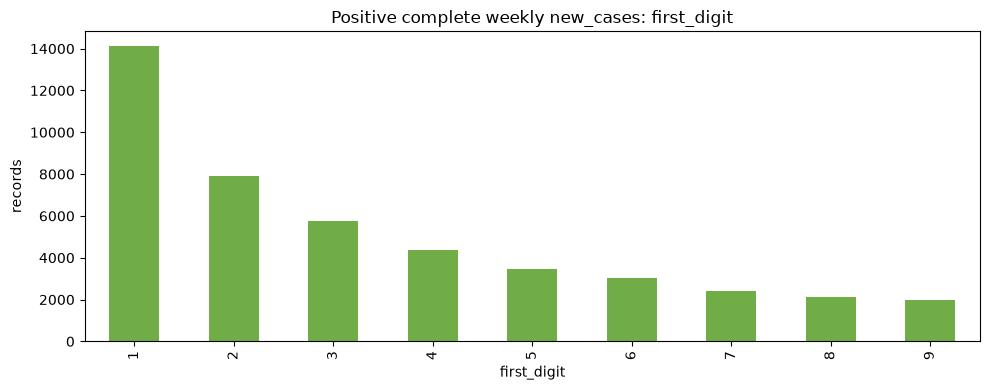

,count
first_2_digits,
10,1815
11,1564
12,1436
13,1370
14,1202
...,...
95,160
96,160
97,138


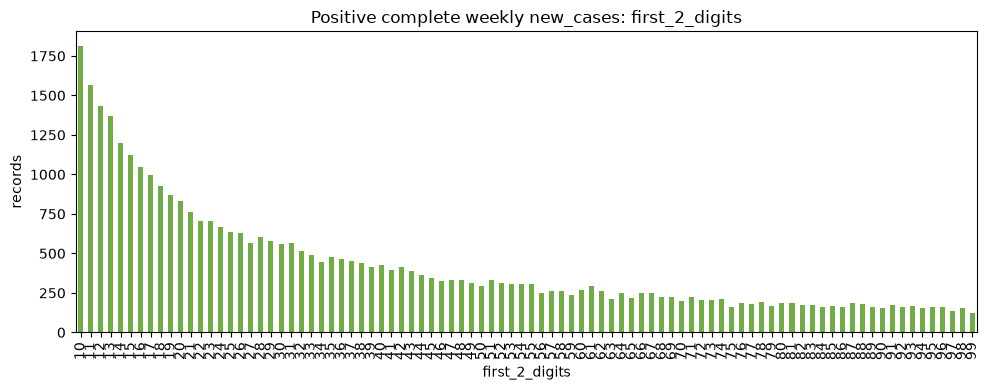

,count
first_3_digits,
100,142
101,144
102,146
103,161
104,173
...,...
995,8
996,7
997,7


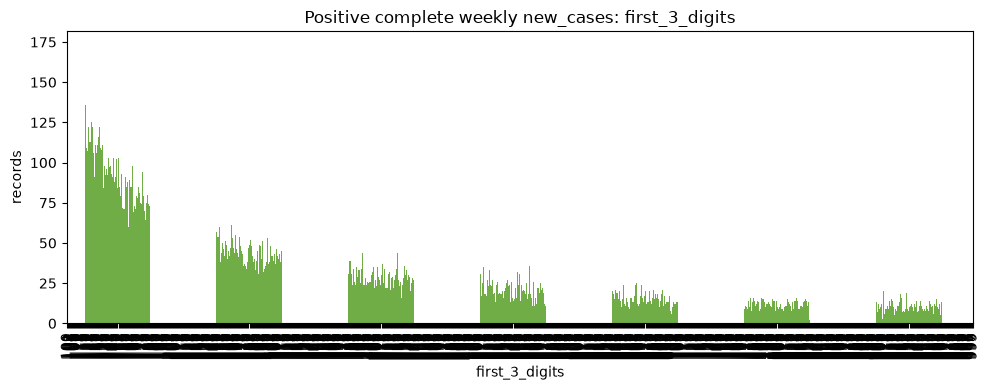

In [4]:
for col in ['first_digit','first_2_digits','first_3_digits']:
    counts=weekly.loc[weekly.positive,col].dropna().astype(str).value_counts().sort_index()
    display(counts.to_frame('count'))
    counts.plot.bar(figsize=(10,4),color='#70ad47',title='Positive complete weekly new_cases: '+col)
    plt.xlabel(col); plt.ylabel('records'); plt.tight_layout(); plt.show()

## 4. Descriptor distributions

The notebook examines coverage and skew for population density, median age, life expectancy, GDP per capita and cumulative vaccination counts. log10 is used only for visualisation and does not overwrite the target.

,field,rows,positive_values,missing_pct
0,population_density,81936,80148,2.182


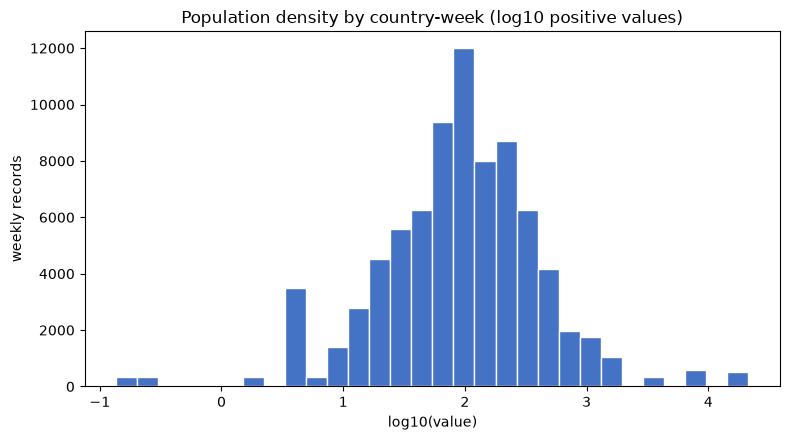

,field,rows,positive_values,missing_pct
0,median_age,81936,81540,0.483


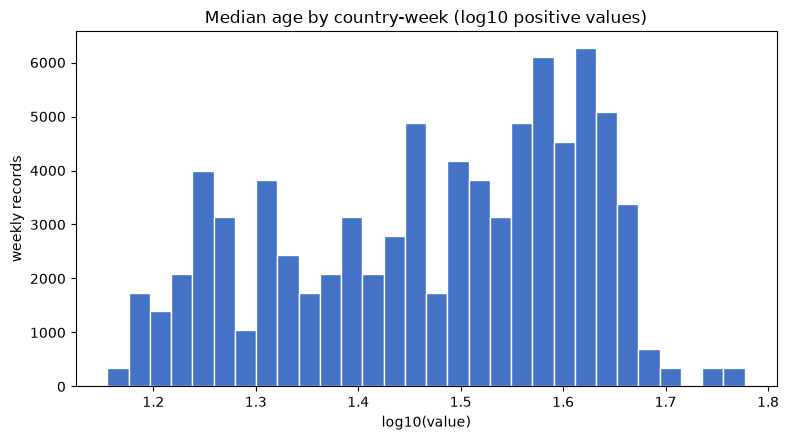

,field,rows,positive_values,missing_pct
0,life_expectancy,81936,81540,0.483


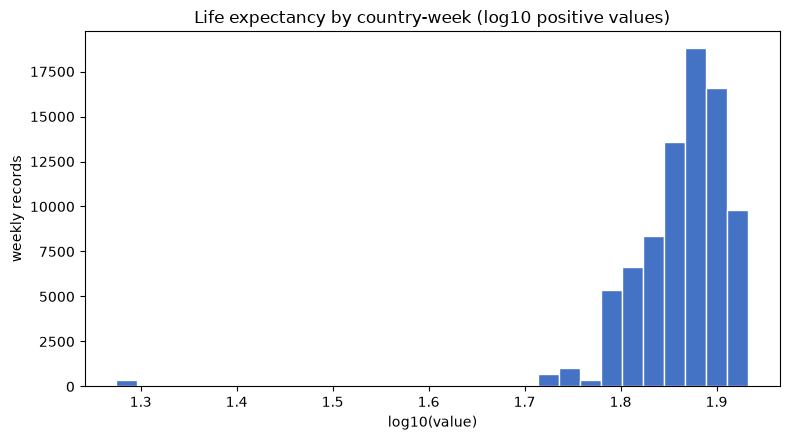

,field,rows,positive_values,missing_pct
0,gdp_per_capita,81936,68794,16.039


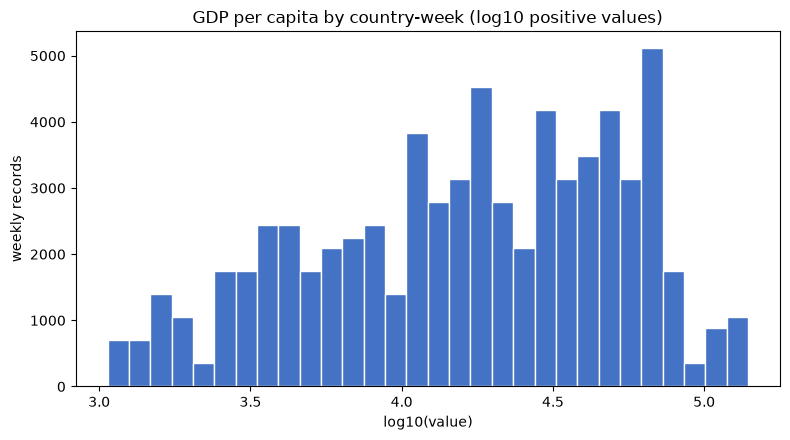

,field,rows,positive_values,missing_pct
0,total_vaccinations,81936,17610,78.417


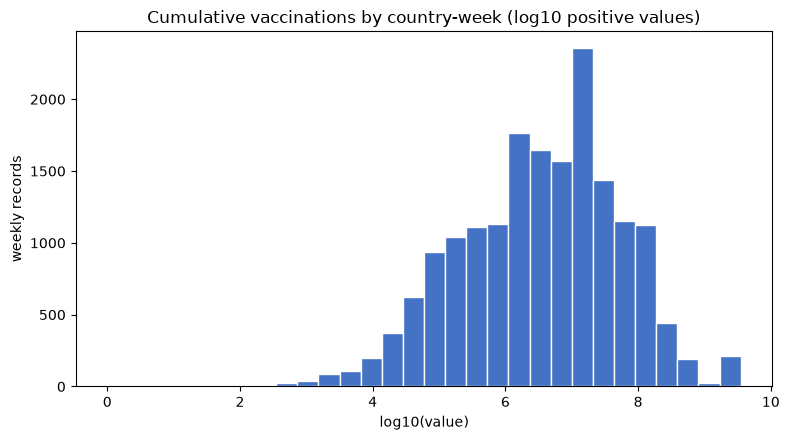

In [5]:
for col,title in [('population_density','Population density'),('median_age','Median age'),('life_expectancy','Life expectancy'),('gdp_per_capita','GDP per capita'),('total_vaccinations','Cumulative vaccinations')]:
    values=weekly.loc[weekly[col].gt(0),col].dropna()
    display(pd.DataFrame({'field':[col],'rows':[len(weekly)],'positive_values':[len(values)],'missing_pct':[round(weekly[col].isna().mean()*100,3)]}))
    plt.figure(figsize=(8,4.5)); plt.hist(np.log10(values),bins=30,color='#4472c4',edgecolor='white')
    plt.title(title+' by country-week (log10 positive values)'); plt.xlabel('log10(value)'); plt.ylabel('weekly records'); plt.tight_layout(); plt.show()

## 5. Pre-meeting conclusion

K=1 has the broadest coverage, K=2 is a practical extension, and K=3 is more selective for COVID. Bart should confirm the analytical unit, descriptor handling and quality measure before the EMM input is frozen.